### Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(24)

---
## Markov Decision Process (MDP) Framework

The MDP with the Bellman optimality equation:

$$V^*(s) = \sup_{a \in \mathcal{A}} \left\{ \mathbb{E}[r(s,a)] + \gamma \, \mathbb{E}_{s' \sim P(s,a)}[V^*(s')] \right\}$$

We use a simple **GridWorld** environment to illustrate all algorithms.

In [2]:
class GridWorld:
    """
    A simple 4x4 GridWorld MDP.
    State: (row, col). Goal: reach (3,3). Pit: (2,2).
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.goal = (size-1, size-1)
        self.pit = (size//2, size//2)
        self.action_effects = [(-1,0),(1,0),(0,-1),(0,1)]  # U D L R

    def state_id(self, s): return s[0]*self.size + s[1]
    def state_xy(self, sid): return (sid // self.size, sid % self.size)

    def reset(self):
        self.pos = (0, 0)
        return self.state_id(self.pos)

    def step(self, action):
        dr, dc = self.action_effects[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)
        done = False
        if self.pos == self.goal:
            reward, done = +10.0, True
        elif self.pos == self.pit:
            reward, done = -10.0, True
        else:
            reward = -0.1 # small step penalty encourages efficiency
        return self.state_id(self.pos), reward, done

env = GridWorld()
print(f"GridWorld: {env.n_states} states, {env.n_actions} actions")
print(f"Goal state id: {env.state_id(env.goal)}, Pit state id: {env.state_id(env.pit)}")

GridWorld: 16 states, 4 actions
Goal state id: 15, Pit state id: 10


## Temporal-Difference Learning

The TD update is:

$$V^{\pi,(n+1)}(s) \leftarrow V^{\pi,(n)}(s) + \beta_n(s,a) \underbrace{\bigl[ r + \gamma V^{\pi,(n)}(s') - V^{\pi,(n)}(s) \bigr]}_{\text{TD error } \delta_n}$$

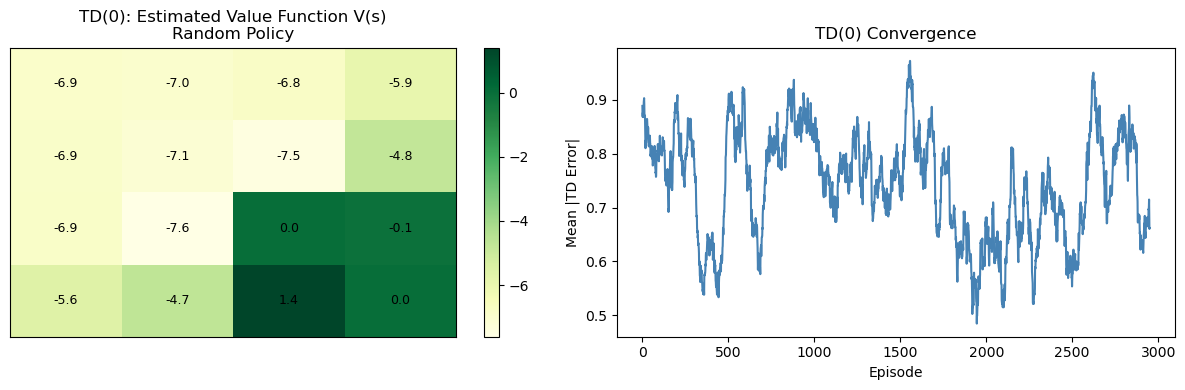

In [3]:
def temporal_dl(env, policy, num_episodes=2000, gamma=0.99, lr=0.1):
    """
    policy: callable(state) to action
    Returns: V (value function array), td_errors (history)
    """
    V = np.zeros(env.n_states)
    td_errors_hist = []

    for _ in range(num_episodes):
        s = env.reset()
        done = False
        ep_td = []
        while not done:
            a = policy(s)
            s_next, r, done = env.step(a)

            # TD error
            td_error = r + gamma * V[s_next] * (1 - done) - V[s]

            # Update rule
            V[s] += lr * td_error
            ep_td.append(abs(td_error))
            s = s_next
        td_errors_hist.append(np.mean(ep_td))

    return V, td_errors_hist

# Evaluate a random policy
random_policy = lambda s: np.random.randint(4)
V_rand, td_errs = temporal_dl(env, random_policy, num_episodes=3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot value function as grid
ax = axes[0]
grid = V_rand.reshape(env.size, env.size)
im = ax.imshow(grid, cmap='YlGn', aspect='auto')
for i in range(env.size):
    for j in range(env.size):
        ax.text(j, i, f"{grid[i,j]:.1f}", ha='center', va='center', fontsize=9)
ax.set_title('TD(0): Estimated Value Function V(s)\nRandom Policy')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax)

# Plot TD error convergence
axes[1].plot(pd_avg := np.convolve(td_errs, np.ones(50)/50, mode='valid'), color='steelblue')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean |TD Error|')
axes[1].set_title('TD(0) Convergence')

plt.tight_layout()
plt.show()